# AdaBoost Immunogenicity Predictor

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, matthews_corrcoef
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import joblib
from utils import save_model
OUTPUT_DIR = "../models"

## Load and Preprocess data

In [2]:
# Load train / validation / test datasets
dataset_train = pd.read_csv("../data/dataset_train.csv")
dataset_val   = pd.read_csv("../data/dataset_val.csv")
dataset_test  = pd.read_csv("../data/dataset_test.csv")

# Drop non-feature columns
DROP_COLS = ["index", "peptide", "HLA", "hla_sequence"]
TARGET_COL = "Label"

# Separate X and y
y_train = dataset_train[TARGET_COL].values
y_val   = dataset_val[TARGET_COL].values
y_test  = dataset_test[TARGET_COL].values

X_train = dataset_train.drop(columns=[TARGET_COL] + [c for c in DROP_COLS if c in dataset_train.columns])
X_val   = dataset_val.drop(columns=[TARGET_COL] + [c for c in DROP_COLS if c in dataset_val.columns])
X_test  = dataset_test.drop(columns=[TARGET_COL] + [c for c in DROP_COLS if c in dataset_test.columns])

# Combine before encoding to make sure all splits have the same columns
X_all = pd.concat(
    [X_train, X_val, X_test],
    axis=0,
    keys=["train", "val", "test"]
)

# Identify categorical columns
cat_cols = X_all.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Encoding categorical columns: {cat_cols}")

# One-hot encode if any categorical columns remain
X_all = pd.get_dummies(X_all, columns=cat_cols)

# Split back
X_train = X_all.loc["train"]
X_val   = X_all.loc["val"]
X_test  = X_all.loc["test"]

print(f"Train: {X_train.shape}, Classes: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Val:   {X_val.shape}, Classes: {dict(zip(*np.unique(y_val, return_counts=True)))}")
print(f"Test:  {X_test.shape}, Classes: {dict(zip(*np.unique(y_test, return_counts=True)))}")

print(X_train.columns.tolist())

Encoding categorical columns: []
Train: (5707, 290), Classes: {np.int64(0): np.int64(3143), np.int64(1): np.int64(2564)}
Val:   (1446, 290), Classes: {np.int64(0): np.int64(778), np.int64(1): np.int64(668)}
Test:  (1815, 290), Classes: {np.int64(0): np.int64(991), np.int64(1): np.int64(824)}
['PeptidePos_p1_f1', 'PeptidePos_p1_f2', 'PeptidePos_p1_f3', 'PeptidePos_p1_f4', 'PeptidePos_p1_f5', 'PeptidePos_p1_f6', 'PeptidePos_p1_f7', 'PeptidePos_p1_f8', 'PeptidePos_p1_f9', 'PeptidePos_p1_f10', 'PeptidePos_p1_f11', 'PeptidePos_p1_f12', 'PeptidePos_p1_f13', 'PeptidePos_p1_f14', 'PeptidePos_p1_f15', 'PeptidePos_p1_f16', 'PeptidePos_p1_f17', 'PeptidePos_p1_f18', 'PeptidePos_p2_f1', 'PeptidePos_p2_f2', 'PeptidePos_p2_f3', 'PeptidePos_p2_f4', 'PeptidePos_p2_f5', 'PeptidePos_p2_f6', 'PeptidePos_p2_f7', 'PeptidePos_p2_f8', 'PeptidePos_p2_f9', 'PeptidePos_p2_f10', 'PeptidePos_p2_f11', 'PeptidePos_p2_f12', 'PeptidePos_p2_f13', 'PeptidePos_p2_f14', 'PeptidePos_p2_f15', 'PeptidePos_p2_f16', 'PeptidePo

## Train AdaBoost Classifier

In [3]:
model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=400,
    learning_rate=0.5,
    random_state=42
)
model.fit(X_train, y_train)
print("Model trained!!")

Model trained!!


In [4]:
MODEL_NAME = "adaboost_v1"

metadata = {
    "dataset": "dataset_train / dataset_val / dataset_test",
    "features_shape": X_train.shape,
    "notes": "AdaBoost with decision stump (max_depth=1), 400 estimators, lr=0.5"
}

# Save model
model_path = save_model(
    model=model,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME,
    metadata=metadata
)

Saved model: ../models/adaboost_v1.pkl
Saved metadata: ../models/adaboost_v1_metadata.json


## Evaluate Model

In [5]:
# Validation
y_val_pred = model.predict(X_val)
y_val_prob = model.predict_proba(X_val)[:, 1]
print("-- Validation --")
print(f"Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, y_val_prob):.4f}")

# Test
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("\n-- Test --")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

-- Validation --
Accuracy : 0.7448
ROC-AUC  : 0.8300

-- Test --
Accuracy : 0.7752
ROC-AUC  : 0.8509
              precision    recall  f1-score   support

           0       0.86      0.70      0.77       991
           1       0.71      0.86      0.78       824

    accuracy                           0.78      1815
   macro avg       0.78      0.78      0.78      1815
weighted avg       0.79      0.78      0.78      1815



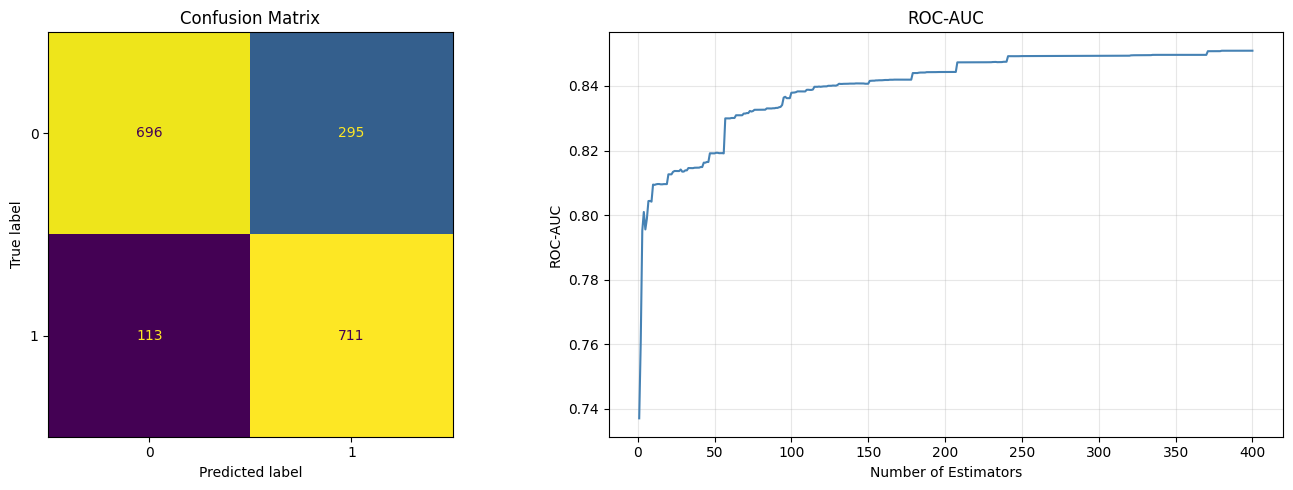

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

staged_auc = [roc_auc_score(y_test, p[:, 1]) for p in model.staged_predict_proba(X_test)]
axes[1].plot(range(1, len(staged_auc) + 1), staged_auc, color="steelblue")
axes[1].set_xlabel("Number of Estimators")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("ROC-AUC")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

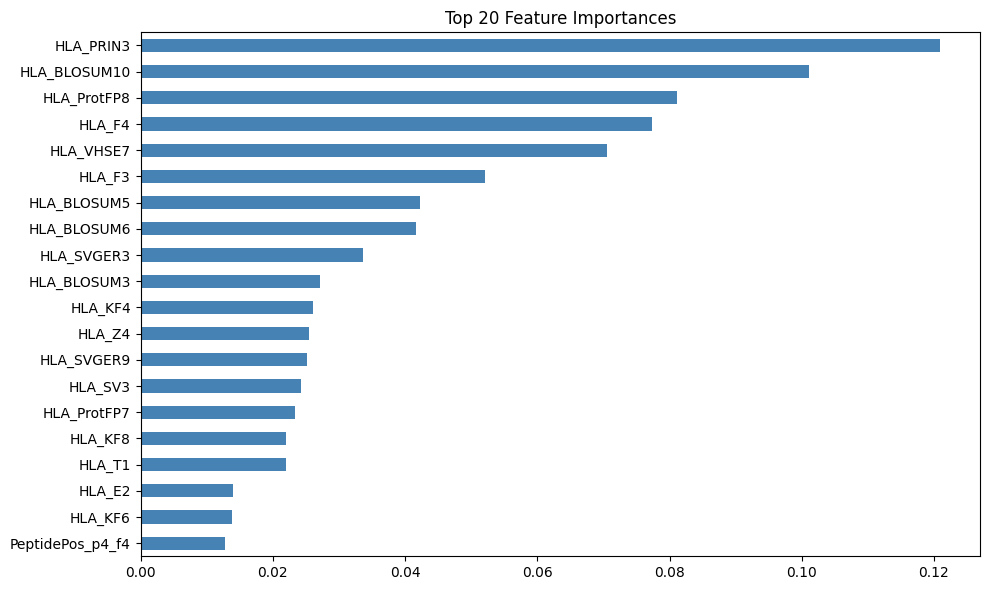

In [7]:
from utils import run_shap_analysis
#run_shap_analysis(model, X_test)
importances = pd.Series(model.feature_importances_, index=X_train.columns)

importances.sort_values(ascending=False).head(20).plot(
    kind="barh",
    color="steelblue",
    figsize=(10, 6)
)

plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

### hyperparameter tuning

In [8]:
# testing different configurations of Adaboost
configs = [
    {"n": 200, "lr": 0.1, "d": 1},
    {"n": 400, "lr": 0.1, "d": 1},
    {"n": 400, "lr": 0.5, "d": 1},
    {"n": 400, "lr": 0.5, "d": 2},
]

In [9]:
results = []
best_model = None
best_score = -1
best_config = None

for i, cfg in enumerate(configs, start=1):
    print(f"\nTraining AdaBoost config {i}: {cfg}")

    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=cfg["d"]),
        n_estimators=cfg["n"],
        learning_rate=cfg["lr"],
        random_state=42
    )

    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)

    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    val_mcc = matthews_corrcoef(y_val, y_val_pred)

    results.append({
        "model_name": f"adaboost_v{i}",
        "n_estimators": cfg["n"],
        "learning_rate": cfg["lr"],
        "max_depth": cfg["d"],
        "val_accuracy": val_accuracy,
        "val_f1": val_f1,
        "val_mcc": val_mcc
    })

    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Validation F1:       {val_f1:.4f}")
    print(f"Validation MCC:      {val_mcc:.4f}")

    # Save each trained model
    save_model(
        model=model,
        output_dir="../models",
        model_name=f"adaboost_v{i}",
        metadata={
            "config": cfg,
            "val_accuracy": val_accuracy,
            "val_f1": val_f1,
            "val_mcc": val_mcc,
            "notes": "AdaBoost hyperparameter tuning model"
        }
    )

    # Choose best model based on MCC
    if val_mcc > best_score:
        best_score = val_mcc
        best_model = model
        best_config = cfg

results_df = pd.DataFrame(results)
display(results_df)

print("\nBest AdaBoost config:")
print(best_config)
print(f"Best validation MCC: {best_score:.4f}")


Training AdaBoost config 1: {'n': 200, 'lr': 0.1, 'd': 1}
Validation Accuracy: 0.7351
Validation F1:       0.7445
Validation MCC:      0.4885
Saved model: ../models/adaboost_v1.pkl
Saved metadata: ../models/adaboost_v1_metadata.json

Training AdaBoost config 2: {'n': 400, 'lr': 0.1, 'd': 1}
Validation Accuracy: 0.7351
Validation F1:       0.7452
Validation MCC:      0.4894
Saved model: ../models/adaboost_v2.pkl
Saved metadata: ../models/adaboost_v2_metadata.json

Training AdaBoost config 3: {'n': 400, 'lr': 0.5, 'd': 1}
Validation Accuracy: 0.7448
Validation F1:       0.7474
Validation MCC:      0.5008
Saved model: ../models/adaboost_v3.pkl
Saved metadata: ../models/adaboost_v3_metadata.json

Training AdaBoost config 4: {'n': 400, 'lr': 0.5, 'd': 2}
Validation Accuracy: 0.7607
Validation F1:       0.7539
Validation MCC:      0.5246
Saved model: ../models/adaboost_v4.pkl
Saved metadata: ../models/adaboost_v4_metadata.json


,model_name,n_estimators,learning_rate,max_depth,val_accuracy,val_f1,val_mcc
0,adaboost_v1,200,0.1,1,0.735131,0.744496,0.488507
1,adaboost_v2,400,0.1,1,0.735131,0.745176,0.489355
2,adaboost_v3,400,0.5,1,0.744813,0.747433,0.500789
3,adaboost_v4,400,0.5,2,0.760719,0.753912,0.524650



Best AdaBoost config:
{'n': 400, 'lr': 0.5, 'd': 2}
Best validation MCC: 0.5246
